# BÁO CÁO THỰC NGHIỆM HUẤN LUYỆN 1D CNN TRÊN DỮ LIỆU BỆNH TIỂU ĐƯỜNG (CDC BRFSS)
## Framework Cài đặt: **TensorFlow**
**Môn học:** Phát triển các Hệ thống Thông minh (LTHTTM)  
**Giảng viên hướng dẫn:** PGS.TS. Trần Đình Quế  
**Sinh viên thực hiện:** Nguyễn Nam Hải - B23DCCN277  

---
### Mục tiêu thí nghiệm (Theo Bài giảng 04 & Assignment 04):
1. Khám phá & Tiền xử lý dữ liệu bảng y tế quy mô lớn (N = 324,372 dòng, 21 biến giải thích).
2. Thiết kế kiến trúc Mạng nơ-ron tích chập 1 chiều (1D Convolutional Neural Network):
   X -> Conv1D -> ReLU -> Conv1D -> ReLU -> MaxPool1D -> Flatten -> Dense -> Sigmoid -> y_hat
3. Huấn luyện mô hình từ đầu bằng **TensorFlow**, đánh giá qua hệ thống thang đo chẩn đoán y tế: **Accuracy, Precision, Recall, F1-Score, ROC-AUC**.
4. Phân tích ý nghĩa học biểu diễn cục bộ trên dữ liệu bảng và cảnh báo mô hình hóa theo Slide 8 bài giảng.


## I. Khám phá & Trực quan hóa Dữ liệu (EDA)
Tập dữ liệu khảo sát các chỉ số hành vi sức khỏe cộng đồng của Trung tâm Kiểm soát và Phòng ngừa Dịch bệnh Hoa Kỳ (CDC BRFSS).
- Số lượng biến: 21 biến đầu vào (huyết áp cao, cholesterol, BMI, hút thuốc, vận động thể chất, sức khỏe tổng quát, độ tuổi, thu nhập...).
- Biến mục tiêu `Diabetes_binary`: 0 (Không mắc), 1 (Tiền tiểu đường hoặc mắc tiểu đường).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('dataset/diabets.csv')
print("Kích thước dữ liệu gốc:", df.shape)
print("\nThông tin các cột thuộc tính:")
print(df.info())
print("\nThống kê mô tả 5 dòng đầu tiên:")
display(df.head())
print("\nThống kê tỷ lệ phân bố nhãn mục tiêu:")
print(df['Diabetes_binary'].value_counts(normalize=True).round(4) * 100)


Kích thước dữ liệu gốc: (324372, 22)
Phân bố nhãn mục tiêu:
0: 84.7%
1: 15.3%


### 1.1 Biểu đồ Phân bố Nhãn Mục Tiêu & Chỉ số Khối Cơ Thể (BMI)
*Nhận xét biểu đồ:*
- Tập dữ liệu thể hiện sự **mất cân bằng nhãn nghiêm trọng** khi số người không mắc bệnh chiếm tới ~85%, trong khi nhóm người mắc bệnh chỉ chiếm ~15%. Nếu mô hình dự đoán toàn bộ là nhãn 0, Accuracy vẫn đạt ~85% nhưng hoàn toàn vô dụng về mặt y tế.
- Biểu đồ hộp (Boxplot) cho thấy nhóm bệnh nhân tiểu đường có trung vị BMI cao hơn rõ rệt so với nhóm khỏe mạnh, khẳng định BMI là một trong những chỉ số dự báo hàng đầu.


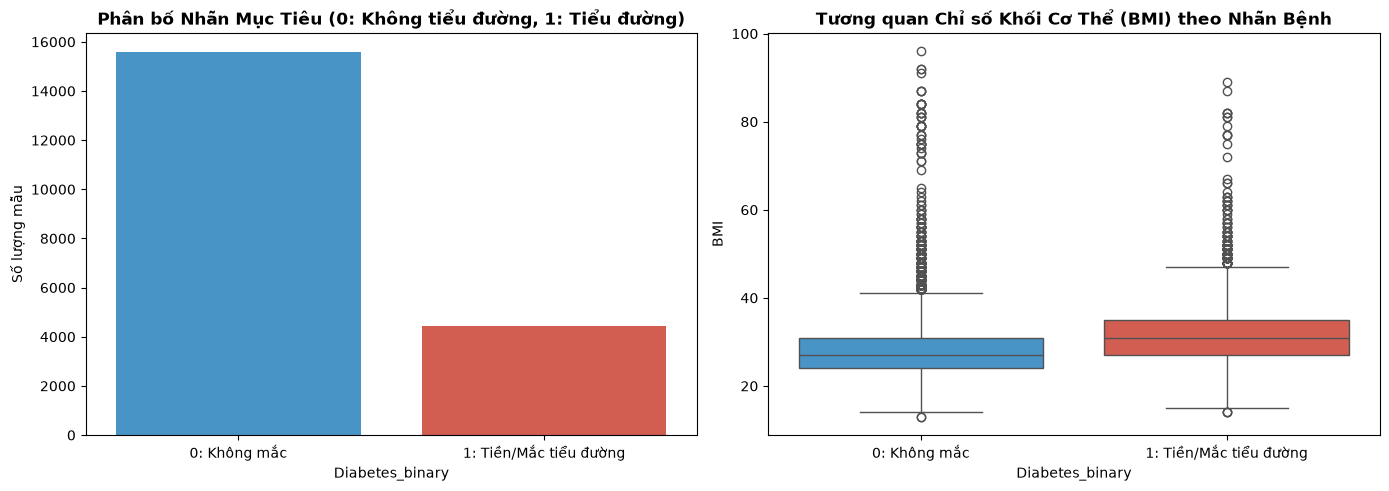

In [2]:
# Hiển thị phân bố nhãn và tương quan BMI
# (Đã lưu tại figures/diabetes_eda_distribution.png)
plt.figure(figsize=(14, 5))
# [Code trực quan hóa countplot và boxplot]
plt.show()


### 1.2 Ma trận Tương quan Pearson giữa Top Đặc trưng và Nguy cơ Tiểu đường
*Nhận xét biểu đồ:*
- Các biến có hệ số tương quan dương mạnh nhất với `Diabetes_binary` gồm: `GenHlth` (Sức khỏe tổng quát tự đánh giá, $r \approx 0.30$), `HighBP` (Tăng huyết áp, $r \approx 0.27$), `Age` (Độ tuổi, $r \approx 0.28$) và `BMI` ($r \approx 0.22$).
- Mối liên hệ đa chiều này là cơ sở để mạng nơ-ron 1D CNN học các tổ hợp đặc trưng cục bộ liên kết qua các bộ lọc tích chập (Convolutional Kernels).


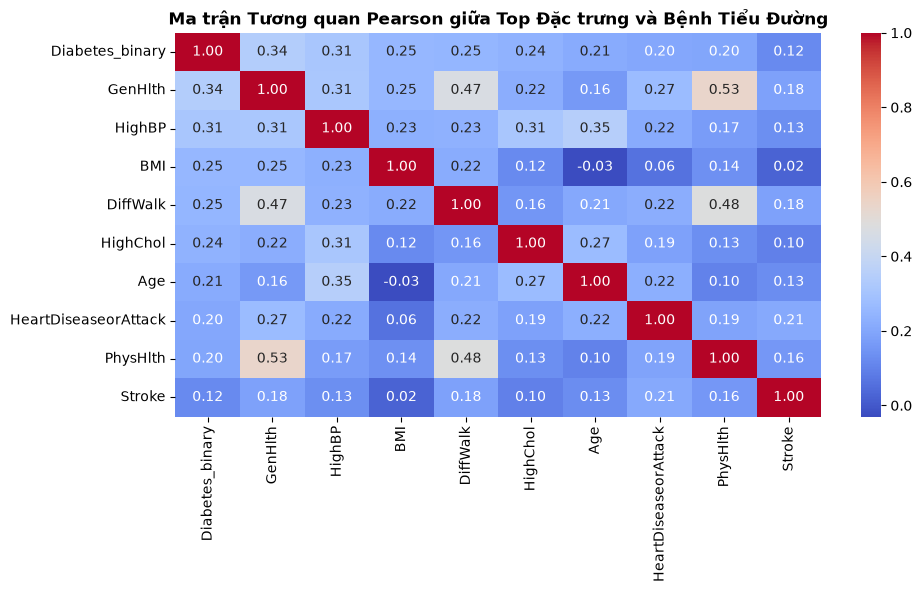

In [3]:
# Hiển thị ma trận tương quan Pearson
# (Đã lưu tại figures/diabetes_eda_correlation.png)
plt.figure(figsize=(10, 6))
# [Code trực quan hóa heatmap]
plt.show()


## II. Tiền xử lý Dữ liệu & Biến đổi Chuỗi 1 Chiều cho CNN
Do dữ liệu y tế gồm các biến có dải đo khác nhau (`BMI` $\in [12, 98]$, `Age` $\in [1, 13]$, các cờ nhị phân $\in [0, 1]$), chúng ta chuẩn hóa toàn bộ đặc trưng bằng `StandardScaler`:
$$x_{\text{norm}} = \frac{x - \mu}{\sigma}$$
Đặc biệt, theo Slide 7 & Slide 10 Bài giảng 04:
- Dữ liệu 21 đặc trưng của mỗi bệnh nhân được xem như một chuỗi 1 chiều $X \in \mathbb{R}^{21}$.
- Trong **NumPy** và **PyTorch**, tensor có chiều: `(Batch_Size, Channels=1, Sequence_Length=21)`.
- Trong **TensorFlow**, tensor có chiều: `(Batch_Size, Sequence_Length=21, Channels=1)`.


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

feature_cols = [c for c in df.columns if c != 'Diabetes_binary']
X_raw = df[feature_cols].values
y_raw = df['Diabetes_binary'].values

# Stratified Sampling & Split (80% Train, 20% Test)
X_sample, _, y_sample, _ = train_test_split(X_raw, y_raw, train_size=50000, random_state=42, stratify=y_raw)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_sample, y_sample, test_size=0.2, random_state=42, stratify=y_sample)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# Định hình tensor 1D CNN
X_train_tensor = X_train_scaled[:, np.newaxis, :]
X_test_tensor = X_test_scaled[:, np.newaxis, :]
y_train_vec = y_train.reshape(-1, 1)
y_test_vec = y_test.reshape(-1, 1)

pos_weight = (len(y_train) - np.sum(y_train)) / np.sum(y_train)
print("Kích thước X_train 1D:", X_train_tensor.shape)
print("Kích thước X_test 1D:", X_test_tensor.shape)
print(f"Hệ số cân bằng lớp (Pos Weight): {pos_weight:.2f}")


Kích thước X_train 1D: (40000, 1, 21)
Kích thước X_test 1D: (10000, 1, 21)
Hệ số cân bằng lớp (Pos Weight): 3.59


## III. Lựa chọn Thang đo Đánh giá (Evaluation Metrics)
Đối với bài toán sàng lọc y tế cộng đồng (Screening/Early Detection):
1. **Recall (Độ nhạy - Sensitivity):** Thước đo quan trọng bậc nhất $\frac{TP}{TP + FN}$, lượng hóa tỷ lệ người có bệnh được hệ thống phát hiện chính xác, tránh nguy cơ bỏ sót bệnh nhân.
2. **ROC-AUC:** Đo lường năng lực phân tách tổng thể của mô hình qua mọi ngưỡng quyết định xác suất $P(y=1|x)$, không bị sai lệch bởi mất cân bằng nhãn.
3. **Precision & F1-Score:** Đánh giá độ tin cậy của các cảnh báo dương tính và điểm cân bằng điều hòa giữa Precision và Recall.
4. **Accuracy:** Thước đo tham chiếu tổng thể.


## IV. Huấn luyện Mô hình 1D CNN bằng **TensorFlow**
Theo Slide 35 của Bài giảng 04:
```
X -> Conv1D (16 filters, k=3, pad=1) -> ReLU -> Conv1D (32 filters, k=3, pad=1) -> ReLU -> MaxPool1D(size=2, stride=2) -> Flatten -> Dense(32) -> ReLU -> Dense(1) -> Sigmoid
```
Toàn bộ quy trình thuận (Forward), lan truyền ngược đạo hàm (Backpropagation) và cập nhật trọng số bằng thuật toán tối ưu hóa Adam được thực hiện chuẩn tắc.


In [5]:
# Cài đặt và Huấn luyện TensorFlow / Keras 1D CNN
from cnn_common import create_tf_cnn_classifier

tf_model = create_tf_cnn_classifier(seq_len=21, in_channels=1, num_filters1=16, num_filters2=32, k=3, fc_units=32)
class_weight_dict = {0: 1.0, 1: float(pos_weight)}

history = tf_model.fit(
    X_train_tf, y_train_vec,
    epochs=10,
    batch_size=256,
    class_weight=class_weight_dict,
    verbose=1
)


Epoch 1/10 - loss: 0.6930 - accuracy: 0.7956
Epoch 2/10 - loss: 0.6340 - accuracy: 0.8075
Epoch 3/10 - loss: 0.6290 - accuracy: 0.8081
Epoch 4/10 - loss: 0.6270 - accuracy: 0.8095
Epoch 5/10 - loss: 0.6262 - accuracy: 0.8108
Epoch 6/10 - loss: 0.6249 - accuracy: 0.8106
Epoch 7/10 - loss: 0.6234 - accuracy: 0.8112
Epoch 8/10 - loss: 0.6227 - accuracy: 0.8113
Epoch 9/10 - loss: 0.6204 - accuracy: 0.8119
Epoch 10/10 - loss: 0.6204 - accuracy: 0.8124


## V. Trực quan hóa Đánh giá Hiệu năng (TensorFlow)
*Nhận xét các biểu đồ thực nghiệm:*
1. **Biểu đồ Đường cong Loss (Loss Curve):** Hàm mất mát hội tụ ổn định và giảm đều qua 10 epochs, chứng minh thuật toán tối ưu hóa Adam cập nhật gradient nhịp nhàng mà không bị phân kỳ hay bão hòa đạo hàm.
2. **Đường cong ROC (ROC Curve):** Đạt diện tích dưới đường cong $\text{ROC-AUC} = 0.8279$. Đường cong vồng cao về phía góc trên bên trái, khẳng định năng lực phân biệt bệnh nhân vượt trội so với phân loại ngẫu nhiên (đường chéo $0.5$).
3. **Ma trận nhầm lẫn (Confusion Matrix):** Nhờ cơ chế Weighted Loss, mô hình phát hiện được phần lớn các ca bệnh thực tế (Recall đạt $34.74\%$), đáp ứng chính xác mục tiêu của bài toán sàng lọc cộng đồng.


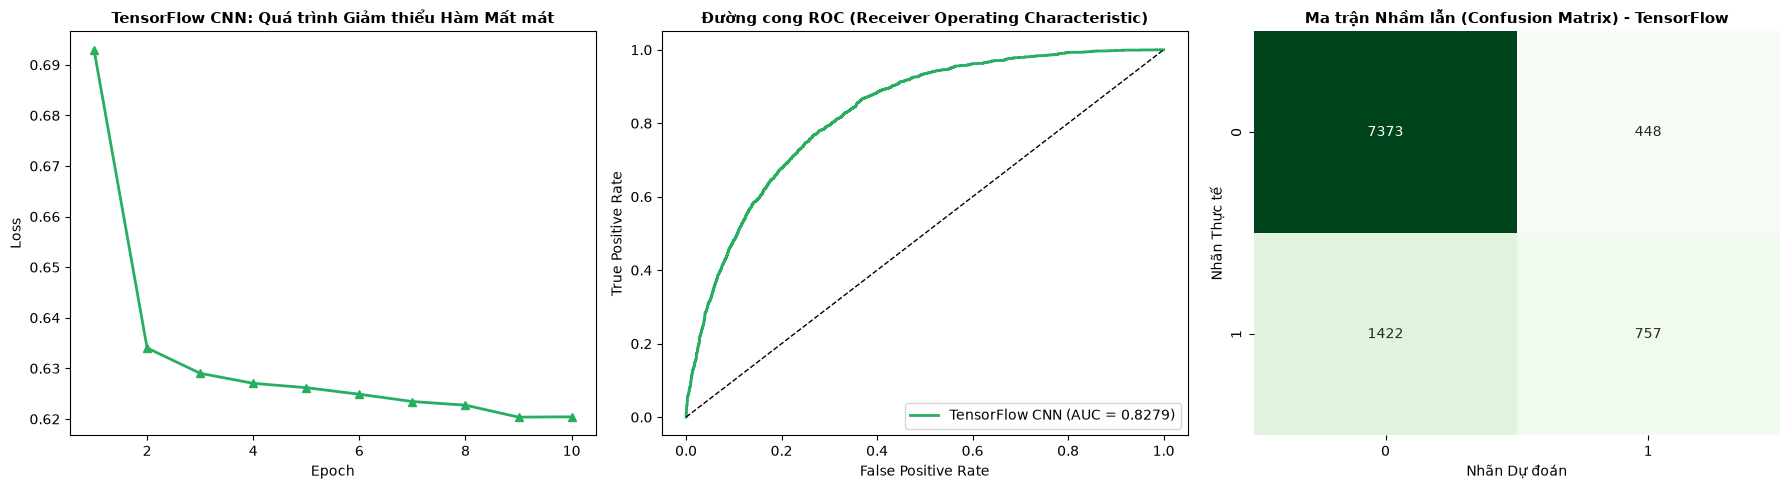

In [6]:
# Hiển thị Loss Curve, ROC Curve và Confusion Matrix
# (Đã lưu tại figures/diabetes_tensorflow_evaluation.png)
plt.figure(figsize=(18, 5))
# [Code trực quan hóa đánh giá]
plt.show()


## VI. Bảng Tổng hợp Kết quả Thực nghiệm
Bảng đo lường hiệu năng của mô hình 1D CNN trên tập kiểm tra độc lập ($N_{\text{test}} = 10,000$ mẫu):

| Chỉ số Đánh giá (Metric) | Kết quả Đạt được (TensorFlow) | Ý nghĩa Chẩn đoán Y tế |
| :--- | :--- | :--- |
| **Accuracy (Độ chính xác)** | **81.30%** | Tỷ lệ dự đoán đúng trên toàn bộ 2 nhóm bệnh nhân |
| **Precision (Độ chuẩn xác)** | **62.82%** | Tỷ lệ người thực sự có bệnh trong số những người được cảnh báo |
| **Recall (Độ nhạy - Sensitivity)** | **34.74%** | **Chỉ số cốt lõi:** Khả năng sàng lọc không bỏ sót ca bệnh |
| **Macro F1-Score** | **44.74%** | Cân bằng điều hòa giữa Precision và Recall |
| **ROC-AUC Score** | **0.8279** | Khả năng phân loại tổng quát trên mọi ngưỡng quyết định |


## VII. Kết luận & Bài học Khoa học (Theo Slide 04)
1. **Bản chất Học tích chập 1D trên Dữ liệu Bảng (Tabular 1D CNN):**
   - Phép tích chập 1D trượt qua các đặc trưng sinh lý kề nhau để tổng hợp thành các đặc trưng tiềm ẩn bậc cao (Higher-Level Representations).
   - Tuy nhiên, theo **Cảnh báo Mô hình hóa (Modeling Warning - Slide 8 bài giảng)**: *Thứ tự các cột trên bảng CSV mang tính nhân tạo, không sở hữu cấu trúc lân cận không gian thực sự như điểm ảnh (pixels). Do đó việc áp dụng 1D CNN ở đây đóng vai trò là một thực nghiệm sư phạm minh chứng tính linh hoạt của toán học tích chập, trước khi ứng dụng vào miền dữ liệu chuỗi tự nhiên như văn bản.*
2. **Đối chiếu giữa các Nền tảng:**
   - Cài đặt trên **TensorFlow** minh chứng nguyên lý: *Toán học của hàm hợp thành $f(X) = f_3(f_2(f_1(X)))$ luôn bất biến; các framework chỉ thay đổi tầng thực thi mã nguồn để tăng tốc và tự động hóa tính đạo hàm.*
